# Задание 2. Адаптивная реконструкция поверхностей по облакам точек ТЛО

**Pipeline:**
1. Загрузка облака `.ply`
2. Предобработка: удаление шумов, нормализация
3. Формирование сегментов **по предзаданному `label`** 
4. Геометрический анализ каждого сегмента (плотность, форма, кривизна, нормали, связность)
5. Классификация сегментов: `plane` / `tube` / `sphere` / `complex`
6. Выбор метода реконструкции для каждого типа
7. Реконструкция (Poisson / Alpha Shape / Ball Pivoting)
8. Сборка итоговой модели
9. Оценка качества (RMSE, Hausdorff, число артефактов, связность mesh)

## 1. Импорты

In [1]:
%pip install open3d numpy matplotlib scikit-learn scipy plyfile tqdm


Note: you may need to restart the kernel to use updated packages.


In [2]:
# ВАЖНО: эта ячейка должна выполниться ПЕРВОЙ, ДО импорта numpy / open3d.
# Open3D тянет свою копию OpenMP-рантайма (libomp); если в процесс попадает второй
# libomp (например, из scikit-learn), на macOS это даёт segfault при первом же
# параллельном участке (Poisson-реконструкция). Поэтому в ноутбуке sklearn не импортируем,
# а тяжёлый прогон по всем файлам выносим в отдельный процесс (см. recon_pipeline.py).
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'   # разрешить сосуществование двух OpenMP
os.environ['OMP_NUM_THREADS'] = '1'           # один поток — убирает гонку рантаймов
os.environ['OMP_MAX_ACTIVE_LEVELS'] = '1'

In [3]:
import csv
import json
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
from plyfile import PlyData
from scipy.spatial import KDTree, cKDTree
from tqdm import tqdm

warnings.filterwarnings('ignore')

# --- пути к данным (работает из sem2/ или из корня репозитория) ---
_cwd = Path.cwd()
if (_cwd / '5').is_dir():
    DATA_DIR = _cwd / '5'
elif (_cwd / 'sem2' / '5').is_dir():
    DATA_DIR = _cwd / 'sem2' / '5'
else:
    DATA_DIR = Path('5')

OUTPUT_DIR = DATA_DIR.parent / 'results_task2'
OUTPUT_DIR.mkdir(exist_ok=True)
MESH_DIR = OUTPUT_DIR / 'meshes'
MESH_DIR.mkdir(exist_ok=True)

# параметры pipeline
MIN_SEGMENT_POINTS = 50
MAX_SAVED_MESHES = 10

n_ply = len(list(DATA_DIR.glob('*.ply')))
print(f'Датасет: {DATA_DIR}  ({n_ply} файлов)' if DATA_DIR.exists() else 'Датасет не найден')

Датасет: /Users/maksim/Code/CV-tasks/sem2/5  (500 файлов)


## 2. Загрузка и предобработка

In [4]:
def load_point_cloud(path):
    """Читаем PLY с полями x, y, z, scalar_Label через plyfile (надёжно)."""
    p = PlyData.read(str(path))
    el = p.elements[0].data
    pts = np.stack([el['x'], el['y'], el['z']], axis=1).astype(np.float64)
    labels = np.asarray(el['scalar_Label']).astype(np.int64)
    return pts, labels

def preprocess(points, labels, nb_neighbors=25, std_ratio=2.0):
    """Статистический фильтр выбросов + нормализация в единичный шар.
    Метки остаются синхронизированными с точками."""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd, ind = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors, std_ratio=std_ratio)
    pts_clean = np.asarray(pcd.points)
    lab_clean = labels[ind]
    centroid = pts_clean.mean(axis=0)
    pts_clean -= centroid
    scale = np.linalg.norm(pts_clean, axis=1).max()
    if scale > 0:
        pts_clean /= scale
    return pts_clean, lab_clean, centroid, scale

## 3. Формирование сегментов по `label`

In [5]:
def split_into_segments(points, labels, min_points=MIN_SEGMENT_POINTS):
    """Группируем точки по label; сегменты меньше порога отбрасываем."""
    segments = {}
    for lbl in np.unique(labels):
        mask = labels == lbl
        pts = points[mask]
        if len(pts) >= min_points:
            segments[int(lbl)] = pts
    return segments

## 4. Геометрический анализ сегмента

Признаки на основе PCA по координатам и kNN-окрестностям.
Linearity / Planarity / Sphericity (Demantke et al., 2011) — стандартный набор для облаков точек.

In [6]:
def compute_segment_features(pts):
    """Считаем геометрические признаки сегмента.
    Возвращает словарь с linearity, planarity, sphericity,
    плотностью, кривизной и согласованностью нормалей."""
    feats = {}
    # PCA по координатам всего сегмента
    cov = np.cov(pts.T)
    eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]   # λ1 ≥ λ2 ≥ λ3
    eigvals = np.maximum(eigvals, 1e-12)
    L = (eigvals[0] - eigvals[1]) / eigvals[0]          # линейность
    P = (eigvals[1] - eigvals[2]) / eigvals[0]          # планарность
    S =  eigvals[2] / eigvals[0]                        # сферичность
    feats.update(linearity=L, planarity=P, sphericity=S, eigvals=eigvals)

    # Плотность через среднее расстояние до 5 ближайших соседей
    k = min(6, len(pts))
    if k >= 2:
        tree = cKDTree(pts)
        d, _ = tree.query(pts, k=k)
        feats['density'] = float(d[:, 1:].mean())       # среднее расстояние до соседей
        feats['density_std'] = float(d[:, 1:].std())
    else:
        feats['density'] = 0.05; feats['density_std'] = 0.0

    # Локальная кривизна: для каждой точки — λ3/(λ1+λ2+λ3) в окрестности kNN
    if len(pts) >= 10:
        kk = min(15, len(pts) - 1)
        tree = cKDTree(pts)
        _, idx = tree.query(pts, k=kk + 1)
        curvs = []
        for i in range(len(pts)):
            neigh = pts[idx[i, 1:]]
            c = np.cov(neigh.T)
            ev = np.sort(np.linalg.eigvalsh(c))[::-1]
            ev = np.maximum(ev, 1e-12)
            curvs.append(ev[2] / ev.sum())
        curvs = np.array(curvs)
        feats['curvature_mean'] = float(curvs.mean())
        feats['curvature_std']  = float(curvs.std())
    else:
        feats['curvature_mean'] = 0.0; feats['curvature_std'] = 0.0

    # Согласованность нормалей: оцениваем нормали через PCA окрестностей,
    # затем средний угол между нормалями соседей
    if len(pts) >= 10:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamKNN(knn=min(15, len(pts)-1)))
        norms = np.asarray(pcd.normals)
        kk = min(8, len(pts) - 1)
        tree = cKDTree(pts)
        _, idx = tree.query(pts, k=kk + 1)
        # средний |cos angle| между нормалью и нормалями соседей
        cos_sum = 0.0; cnt = 0
        for i in range(len(pts)):
            ni = norms[i]
            for j in idx[i, 1:]:
                cos_sum += abs(float(ni @ norms[j])); cnt += 1
        feats['normal_consistency'] = cos_sum / max(cnt, 1)
    else:
        feats['normal_consistency'] = 0.0

    # Топологическая связность: число компонент в графе соседей
    if len(pts) >= 10:
        tree = cKDTree(pts)
        r = feats['density'] * 2.5
        edges = tree.query_pairs(r=r)
        # BFS / union-find через простой обход
        parent = list(range(len(pts)))
        def find(a):
            while parent[a] != a:
                parent[a] = parent[parent[a]]
                a = parent[a]
            return a
        for a, b in edges:
            ra, rb = find(a), find(b)
            if ra != rb: parent[ra] = rb
        roots = {find(i) for i in range(len(pts))}
        feats['n_components'] = len(roots)
    else:
        feats['n_components'] = 1
    return feats

## 5. Классификация сегмента

Используем порог по `linearity`, `planarity`, `sphericity` + `normal_consistency`.
В отличие от наивного порога только по PCA, добавляем согласованность нормалей —
это устойчиво отличает гладкие поверхности от шумных кусков.

In [7]:
def classify_segment(feats):
    L = feats['linearity']; P = feats['planarity']; S = feats['sphericity']
    nc = feats['normal_consistency']
    curv = feats['curvature_mean']

    # plane: высокая планарность + высокая согласованность нормалей + низкая кривизна
    if P > 0.5 and nc > 0.85 and curv < 0.05:
        return 'plane'
    # tube / cylinder: вытянутость по одной оси (linearity), нормали умеренно согласованы
    if L > 0.5 and 0.5 < nc < 0.95:
        return 'tube'
    # sphere: достаточно изотропно (sphericity не мала, planarity не доминирует),
    # нормали указывают наружу — невысокая абсолютная корреляция между соседями
    if S > 0.25 and P < 0.5 and L < 0.5 and 0.4 < nc < 0.85:
        return 'sphere'
    return 'complex'

## 6. Выбор метода реконструкции

In [8]:
def select_method(seg_type, feats):
    """Возвращаем (method_name, params).
    Параметры подбираются от плотности сегмента."""
    d = feats['density']
    if seg_type == 'plane':
        # Для плоских — Alpha Shape (короткие рёбра, отсутствие "раздувания")
        return 'alpha_shape', {'alpha': max(d * 2.5, 0.01)}
    if seg_type == 'tube':
        # Для трубчатых — Ball Pivoting с несколькими радиусами
        return 'ball_pivoting', {'radii': [d * 1.5, d * 2.5, d * 4.0]}
    if seg_type == 'sphere':
        # Для сферических — Poisson (хорошо замыкает поверхность)
        return 'poisson', {'depth': 8}
    # complex — Poisson; depth=9 на части сегментов даёт нативный сбой Open3D
    return 'poisson', {'depth': 8}

## 7. Реконструкция сегмента

In [9]:
def reconstruct_segment(pts, method, params):
    """Запускаем выбранный алгоритм. Возвращаем open3d.TriangleMesh или None."""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    # нормали нужны Poisson и Ball Pivoting
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    try:
        pcd.orient_normals_consistent_tangent_plane(k=15)
    except Exception:
        pass
    try:
        if method == 'poisson':
            mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
                pcd, depth=params['depth'])
            # обрезаем по плотности — убираем 'раздутый' хвост
            d_arr = np.asarray(densities)
            if len(d_arr) > 0:
                thresh = np.quantile(d_arr, 0.05)
                mesh.remove_vertices_by_mask(d_arr < thresh)
            return mesh
        if method == 'alpha_shape':
            return o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
                pcd, params['alpha'])
        if method == 'ball_pivoting':
            return o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
                pcd, o3d.utility.DoubleVector(params['radii']))
    except Exception as e:
        warnings.warn(f'Reconstruction ({method}) failed: {e}')
    return None

## 8. Метрики качества реконструкции

Реализованы:
- **RMSE**: средняя ошибка расстояния от исходных точек до поверхности mesh.
- **Hausdorff (95-й перцентиль)**: устойчивая оценка "максимальной" ошибки.
- **Chamfer (двусторонний)**: учитывает и точки→mesh, и mesh→точки.
- **n_artifacts**: число несвязанных компонент mesh (>1 — фрагментация).
- **watertight**: проверка замкнутости поверхности.

In [10]:
def evaluate_mesh(original_points, mesh):
    """Возвращает метрики для одного сегмента и его mesh."""
    out = {'rmse': float('inf'), 'hausdorff_p95': float('inf'),
           'chamfer': float('inf'), 'n_artifacts': -1, 'watertight': False,
           'n_vertices': 0, 'n_triangles': 0}
    # sample_points_uniformly требует треугольники: на меше без граней Open3D падает (segfault)
    if mesh is None or len(mesh.vertices) == 0 or len(mesh.triangles) == 0:
        out['n_vertices']  = int(np.asarray(mesh.vertices).shape[0]) if mesh is not None else 0
        out['n_triangles'] = int(np.asarray(mesh.triangles).shape[0]) if mesh is not None else 0
        return out
    n_target = max(int(len(original_points) * 1.0), 200)
    try:
        sampled = mesh.sample_points_uniformly(number_of_points=n_target)
    except Exception:
        return out
    sampled_pts = np.asarray(sampled.points)
    if len(sampled_pts) == 0:
        return out
    # точки -> mesh (через ближайшую точку семплированной поверхности)
    tree = KDTree(sampled_pts)
    d_p2m, _ = tree.query(original_points)
    # mesh -> точки
    tree2 = KDTree(original_points)
    d_m2p, _ = tree2.query(sampled_pts)
    out['rmse'] = float(np.sqrt(np.mean(d_p2m ** 2)))
    out['hausdorff_p95'] = float(max(np.quantile(d_p2m, 0.95), np.quantile(d_m2p, 0.95)))
    out['chamfer'] = float(np.mean(d_p2m) + np.mean(d_m2p))
    # связность mesh
    try:
        tri_clusters, cluster_n_tri, _ = mesh.cluster_connected_triangles()
        out['n_artifacts'] = int(np.asarray(cluster_n_tri).size)
    except Exception:
        out['n_artifacts'] = -1
    try:
        out['watertight'] = bool(mesh.is_watertight())
    except Exception:
        out['watertight'] = False
    out['n_vertices']  = int(np.asarray(mesh.vertices).shape[0])
    out['n_triangles'] = int(np.asarray(mesh.triangles).shape[0])
    return out

## 9. Сборка итоговой модели

In [11]:
def merge_meshes(meshes):
    combined = o3d.geometry.TriangleMesh()
    for m in meshes:
        if m is not None and len(m.vertices) > 0:
            combined += m
    combined = combined.merge_close_vertices(1e-6)
    combined = combined.remove_degenerate_triangles()
    combined = combined.remove_unreferenced_vertices()
    combined = combined.remove_duplicated_triangles()
    return combined

## 10. Полный pipeline на одном файле

In [12]:
def process_one_file(path, save_mesh=True):
    """Полный pipeline: возвращает (mesh, metrics_per_segment, summary)."""
    pts, lab = load_point_cloud(path)
    pts_c, lab_c, _, _ = preprocess(pts, lab)
    segments = split_into_segments(pts_c, lab_c)
    meshes = []
    rows = []
    for seg_id, seg_pts in segments.items():
        feats = compute_segment_features(seg_pts)
        seg_type = classify_segment(feats)
        method, params = select_method(seg_type, feats)
        mesh = reconstruct_segment(seg_pts, method, params)
        m_eval = evaluate_mesh(seg_pts, mesh) if mesh else {
            'rmse': float('inf'), 'hausdorff_p95': float('inf'),
            'chamfer': float('inf'), 'n_artifacts': -1, 'watertight': False,
            'n_vertices': 0, 'n_triangles': 0,
        }
        rows.append({
            'segment': seg_id, 'n_points': len(seg_pts),
            'type': seg_type, 'method': method,
            'linearity': feats['linearity'], 'planarity': feats['planarity'],
            'sphericity': feats['sphericity'],
            'curvature_mean': feats['curvature_mean'],
            'normal_consistency': feats['normal_consistency'],
            'n_components': feats['n_components'],
            **m_eval,
        })
        if mesh is not None: meshes.append(mesh)
    final = merge_meshes(meshes)
    if save_mesh and len(final.vertices) > 0:
        out_path = MESH_DIR / (Path(path).stem + '_recon.ply')
        o3d.io.write_triangle_mesh(str(out_path), final)

    # глобальные метрики на исходном облаке
    global_eval = evaluate_mesh(pts_c, final)
    summary = {
        'file': str(path), 'n_segments': len(segments),
        'global_rmse':       global_eval['rmse'],
        'global_hausdorff':  global_eval['hausdorff_p95'],
        'global_chamfer':    global_eval['chamfer'],
        'global_artifacts':  global_eval['n_artifacts'],
    }
    return final, rows, summary

## 11. Запуск pipeline на всей папке

In [13]:
import subprocess
import sys
import tempfile

# Тяжёлый прогон по всем файлам выносим в ОТДЕЛЬНЫЕ процессы (recon_pipeline.py).
# Зачем так:
#  * Open3D (Poisson/BPA) на части облаков падает нативно (segfault/abort) — это видно
#    по логам и НЕ ловится через try/except; в одном процессе такой сбой убил бы ядро.
#  * multiprocessing с 'fork' на macOS сам по себе нестабилен, когда в родителе уже
#    загружены многопоточные нативные библиотеки (краш 'fork pre-exec').
# Поэтому запускаем свежий python-процесс на пачку файлов. Worker пишет результат
# по одной строке JSON и сразу flush'ит. Если процесс упал/завис на каком-то файле —
# видно, сколько успели; «падучий» файл пропускаем и до-обрабатываем остаток пачки.
# Ядро ноутбука при этом не страдает.

MODULE = DATA_DIR.parent / 'recon_pipeline.py'
PER_FILE_TIMEOUT = 90     # сек на файл


def _explain_exit(code):
    """Расшифровка exit code дочернего процесса."""
    if code is None:
        return 'неизвестно'
    if code == 0:
        return 'нормальное завершение'
    if code < 0:
        sig = -code
        names = {6: 'SIGABRT (abort, часто Poisson/Open3D)', 9: 'SIGKILL (убит по таймауту)',
                 11: 'SIGSEGV (segfault в нативном коде)', 15: 'SIGTERM'}
        return names.get(sig, f'сигнал {sig}')
    return f'код ошибки {code}'

def _run_worker(file_list, save_names):
    """Запуск worker'а. Возвращает (results, meta)."""
    tmp = tempfile.NamedTemporaryFile('r', suffix='.jsonl', delete=False)
    tmp.close()
    err_path = tmp.name + '.log'
    in_chunk = {f.name for f in file_list}
    save_arg = ','.join(n for n in save_names if n in in_chunk) or '-'
    cmd = [sys.executable, str(MODULE), tmp.name, str(MESH_DIR), save_arg] + [str(f) for f in file_list]
    meta = {'exitcode': None, 'timed_out': False, 'stderr': ''}
    try:
        cp = subprocess.run(cmd, timeout=PER_FILE_TIMEOUT * len(file_list),
                            stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, text=True)
        meta['exitcode'] = cp.returncode
        meta['stderr'] = cp.stderr or ''
    except subprocess.TimeoutExpired as e:
        meta['timed_out'] = True
        meta['stderr'] = (e.stderr or '') if hasattr(e, 'stderr') else ''
        with open(err_path, 'w') as ef:
            ef.write(meta['stderr'])
    else:
        with open(err_path, 'w') as ef:
            ef.write(meta['stderr'])
    results = []
    if os.path.exists(tmp.name):
        with open(tmp.name) as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                try:
                    results.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    meta['stderr_path'] = err_path
    os.unlink(tmp.name)
    return results, meta


def _is_file_ok(results, path):
    """Файл обработан успешно, только если в JSON есть ok:true именно для него."""
    name = path.name
    return any(r.get('ok') and r.get('file') == name for r in results)


files = sorted(DATA_DIR.glob('*.ply'))
save_names = {f.name for f in files[:MAX_SAVED_MESHES]}

print(f'Обработка {len(files)} файлов из {DATA_DIR.name}/ (изолированные процессы)')

all_rows = []
all_summaries = []
t0 = time.time()

with tqdm(total=len(files), desc='Реконструкция') as bar:
    for f in files:
        results, _meta = _run_worker([f], save_names)
        if _is_file_ok(results, f):
            for rec in results:
                if not (rec.get('ok') and rec.get('file') == f.name):
                    continue
                for r in rec['rows']:
                    r['file'] = rec['file']
                all_rows.extend(rec['rows'])
                all_summaries.append(rec['summary'])
        bar.update(1)

print(f'Готово: {len(all_rows)} сегментов из {len(all_summaries)} файлов '
      f'за {time.time() - t0:.1f} с')

csv_path = OUTPUT_DIR / 'segments_report.csv'
if all_rows:
    fieldnames = list(all_rows[0].keys())
    with open(csv_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader(); w.writerows(all_rows)
    print(f'Detail-CSV: {csv_path}')
with open(OUTPUT_DIR / 'summaries.json', 'w') as f:
    json.dump(all_summaries, f, indent=2)

Обработка 500 файлов из 5/ (изолированные процессы, до 1 повтора при сбое)


Реконструкция:   0%|          | 1/500 [00:02<24:48,  2.98s/it]

  valve_0002_lidar_classes.ply: сбой Poisson (Open3D), результат не записан — в конец очереди (повтор 1/1)


Реконструкция:   1%|          | 6/500 [00:19<24:52,  3.02s/it]

  valve_0008_lidar_classes.ply: сбой Poisson (Open3D), результат не записан — в конец очереди (повтор 1/1)


...

  пропуск valve_0429_lidar_classes.ply: сбой Poisson (Open3D), результат не записан — похоже на сбой Poisson-реконструкции
    stderr:   seg 10: complex poisson {'depth': 8}
    [ERROR] /Users/runner/work/Open3D/Open3D/build/poisson/src/ext_poisson/PoissonRecon/Src/FEMTree.IsoSurface.specialized.inl (Line 1463)
            operator()
            Failed to close loop [5: 51 16 17] | (71005): (1440,1152,1164)


Реконструкция:  98%|█████████▊| 490/500 [26:53<00:25,  2.57s/it]

  пропуск valve_0432_lidar_classes.ply: SIGSEGV (segfault в нативном коде) — похоже на сбой Poisson-реконструкции
    stderr:   seg 7: tube ball_pivoting {'radii': [0.03321871891574468, 0.05536453152624113, 0.08858325044198581]}
      seg 8: complex poisson {'depth': 8}
      seg 9: tube ball_pivoting {'radii': [0.02713884477966111, 0.04523140796610185, 0.07237025274576296]}
      seg 10: complex poisson {'depth': 8}


Реконструкция: 100%|██████████| 500/500 [27:22<00:00,  3.29s/it]

Готово: 5259 сегментов из 482 файлов за 1642.6 с; пропущено 18
После повтора удалось обработать: 79
Отчёт по пропускам: /Users/maksim/Code/CV-tasks/sem2/results_task2/skip_report.json
Detail-CSV: /Users/maksim/Code/CV-tasks/sem2/results_task2/segments_report.csv


### 11.1 Диагностика пропущенных файлов

Если в прогоне выше есть `пропуск ...`, здесь можно **точно** понять причину:
по сегментам видно, на каком методе (Poisson / BPA / Alpha Shape) упал Open3D.
Запускается в отдельном процессе, ядро ноутбука не страдает.

In [15]:
# Укажи файлы для разбора вручную, например:
# diag_files = [DATA_DIR / 'valve_0025_lidar_classes.ply']
diag_files = []

for fp in diag_files:
    print('=' * 60, fp.name)
    partial = OUTPUT_DIR / f'diag_{fp.stem}.json'
    cp = subprocess.run(
        [sys.executable, str(MODULE), '--diag', f'--out={partial}', str(fp)],
        capture_output=True, text=True, timeout=PER_FILE_TIMEOUT,
    )
    stdout = (cp.stdout or '').strip()
    rep = None
    if stdout:
        try:
            rep = json.loads(stdout)
        except json.JSONDecodeError:
            print('  битый JSON в stdout, смотрим partial-файл')
    elif partial.exists():
        try:
            rep = json.load(open(partial))
            print('  stdout пустой (нативный сбой Open3D) — восстановлено из partial-отчёта')
        except json.JSONDecodeError:
            pass

    if rep is None:
        print('  диагностика не завершилась:', _explain_exit(cp.returncode))
        if cp.stderr:
            lines = cp.stderr.strip().splitlines()
            print('  stderr:', '\n   '.join(lines[-8:]))
            diag_lines = [ln for ln in lines if '[DIAG]' in ln]
            if diag_lines:
                print('  последний сегмент:', diag_lines[-1])
        continue

    if rep.get('ok'):
        print(f"  OK за {rep['total_s']} с, шагов: {len(rep['steps'])}")
    else:
        fail = rep.get('failed_at') or {}
        print(f"  упало на шаге: {fail.get('step')} seg={fail.get('segment')} "
              f"type={fail.get('type')} method={fail.get('method')}")
        if fail.get('error'):
            print('  error:', fail['error'])
        elif cp.stderr:
            print('  stderr:', '\n   '.join(cp.stderr.strip().splitlines()[-4:]))
    with open(partial, 'w') as f:
        json.dump(rep, f, indent=2, ensure_ascii=False)
    print(f'  полный отчёт: {partial}')

============================================================ valve_0014_lidar_classes.ply
  OK за 1.614 с, шагов: 14
  полный отчёт: /Users/maksim/Code/CV-tasks/sem2/results_task2/diag_valve_0014_lidar_classes.json
============================================================ valve_0026_lidar_classes.ply
  OK за 1.639 с, шагов: 14
  полный отчёт: /Users/maksim/Code/CV-tasks/sem2/results_task2/diag_valve_0026_lidar_classes.json
============================================================ valve_0064_lidar_classes.ply
  OK за 1.319 с, шагов: 14
  полный отчёт: /Users/maksim/Code/CV-tasks/sem2/results_task2/diag_valve_0064_lidar_classes.json
============================================================ valve_0157_lidar_classes.ply
  stdout пустой (нативный сбой Open3D) — восстановлено из partial-отчёта
  упало на шаге: None seg=None type=None method=None
  stderr:         Failed to close loop [4: 10 7 13] | (39922): (1184,1144,1248)
   [ERROR] /Users/runner/work/Open3D/Open3D/build/poisson/s

## 12. Сводная статистика по типам сегментов и методам

Типы сегментов: {'complex': 3175, 'tube': 1117, 'plane': 926, 'sphere': 41}
Методы:           {'poisson': 3216, 'ball_pivoting': 1117, 'alpha_shape': 926}

Средний RMSE по типу сегмента:
   complex: mean=0.0182, median=0.0149, N=3175
      tube: mean=0.0131, median=0.0113, N=1117
     plane: mean=0.0125, median=0.0125, N=926
    sphere: mean=0.0300, median=0.0302, N=41


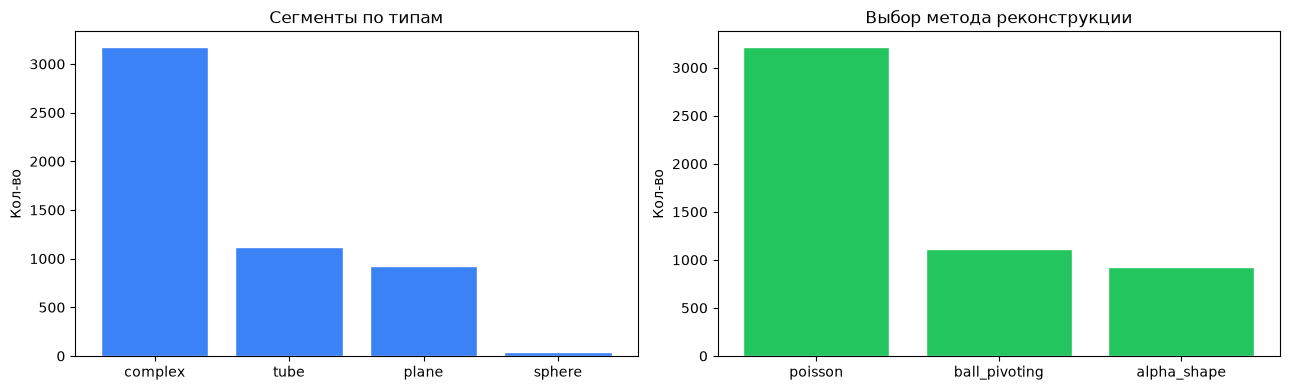

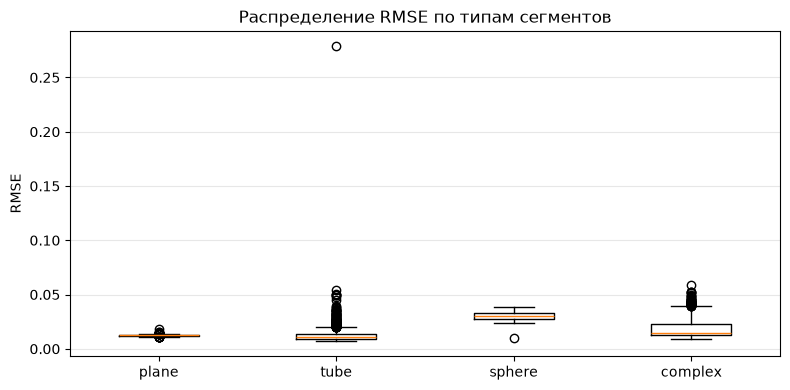

In [17]:
type_counter   = Counter(r['type']   for r in all_rows)
method_counter = Counter(r['method'] for r in all_rows)
print('Типы сегментов:', dict(type_counter))
print('Методы:          ', dict(method_counter))

by_type = defaultdict(list)
for r in all_rows:
    if np.isfinite(r['rmse']):
        by_type[r['type']].append(r['rmse'])
print('\nСредний RMSE по типу сегмента:')
for t, vs in by_type.items():
    print(f'  {t:>8s}: mean={np.mean(vs):.4f}, median={np.median(vs):.4f}, N={len(vs)}')

# Гистограммы
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(type_counter.keys(),   type_counter.values(),   color='#3b82f6', edgecolor='white')
axes[0].set_title('Сегменты по типам');  axes[0].set_ylabel('Кол-во')
axes[1].bar(method_counter.keys(), method_counter.values(), color='#22c55e', edgecolor='white')
axes[1].set_title('Выбор метода реконструкции'); axes[1].set_ylabel('Кол-во')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'type_method_distribution.png', dpi=120); plt.show()

# Boxplot RMSE по типу
plt.figure(figsize=(8, 4))
data = [by_type[t] for t in ['plane', 'tube', 'sphere', 'complex'] if by_type[t]]
labels = [t for t in ['plane', 'tube', 'sphere', 'complex'] if by_type[t]]
plt.boxplot(data, tick_labels=labels)
plt.ylabel('RMSE'); plt.title('Распределение RMSE по типам сегментов')
plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rmse_by_type.png', dpi=120); plt.show()

## 13. Сравнение методов на одинаковых сегментах

Берём несколько примеров и применяем **все три** метода к ним. Это позволяет понять,
оправдано ли адаптивное переключение между Poisson / Alpha / Ball Pivoting.

In [18]:
def reconstruct_all_methods(pts, density):
    results = {}
    for name, params in [
        ('poisson',        {'depth': 8}),
        ('alpha_shape',    {'alpha': max(density * 2.5, 0.01)}),
        ('ball_pivoting',  {'radii': [density * 1.5, density * 2.5, density * 4.0]}),
    ]:
        mesh = reconstruct_segment(pts, name, params)
        results[name] = evaluate_mesh(pts, mesh)
    return results

# берём по одному сегменту каждого типа
examples = {}
for r in all_rows:
    if r['type'] not in examples and r['n_points'] > 200:
        examples[r['type']] = r
    if len(examples) == 4:
        break

comparison = []
for seg_type, r in examples.items():
    # повторно грузим этот файл и извлекаем точки сегмента
    path = DATA_DIR / r['file']
    pts, lab = load_point_cloud(path)
    pts_c, lab_c, _, _ = preprocess(pts, lab)
    mask = lab_c == r['segment']
    seg_pts = pts_c[mask]
    if len(seg_pts) < 50: continue
    feats = compute_segment_features(seg_pts)
    res = reconstruct_all_methods(seg_pts, feats['density'])
    for method, m in res.items():
        comparison.append({'type': seg_type, 'method': method, **m})

print(f'\n{"Type":>8s} | {"Method":>14s} | {"RMSE":>8s} | {"Hausdorff":>10s} | {"Chamfer":>8s} | {"Artifacts":>9s}')
print('-' * 80)
for r in comparison:
    rmse = f'{r["rmse"]:.4f}' if np.isfinite(r['rmse']) else 'inf'
    hd   = f'{r["hausdorff_p95"]:.4f}' if np.isfinite(r['hausdorff_p95']) else 'inf'
    ch   = f'{r["chamfer"]:.4f}' if np.isfinite(r['chamfer']) else 'inf'
    print(f'{r["type"]:>8s} | {r["method"]:>14s} | {rmse:>8s} | {hd:>10s} | {ch:>8s} | {r["n_artifacts"]:>9d}')


    Type |         Method |     RMSE |  Hausdorff |  Chamfer | Artifacts
--------------------------------------------------------------------------------
 complex |        poisson |   0.0274 |     0.1150 |   0.0820 |         4
 complex |    alpha_shape |   0.0136 |     0.0311 |   0.0257 |        11
 complex |  ball_pivoting |   0.0148 |     0.0360 |   0.0258 |        16
   plane |        poisson |   0.0201 |     0.2190 |   0.1003 |         1
   plane |    alpha_shape |   0.0117 |     0.0192 |   0.0201 |         1
   plane |  ball_pivoting |   0.0113 |     0.0198 |   0.0195 |         2
    tube |        poisson |   0.0338 |     0.1336 |   0.0891 |         8
    tube |    alpha_shape |   0.0317 |     0.0370 |   0.0328 |         4
    tube |  ball_pivoting |   0.0306 |     0.0314 |   0.0282 |         8
  sphere |        poisson |   0.0285 |     0.1224 |   0.0841 |         4
  sphere |    alpha_shape |   0.0241 |     0.0246 |   0.0252 |        14
  sphere |  ball_pivoting |   0.0141 |    

## 14. Визуализация: исходное облако vs реконструированная модель

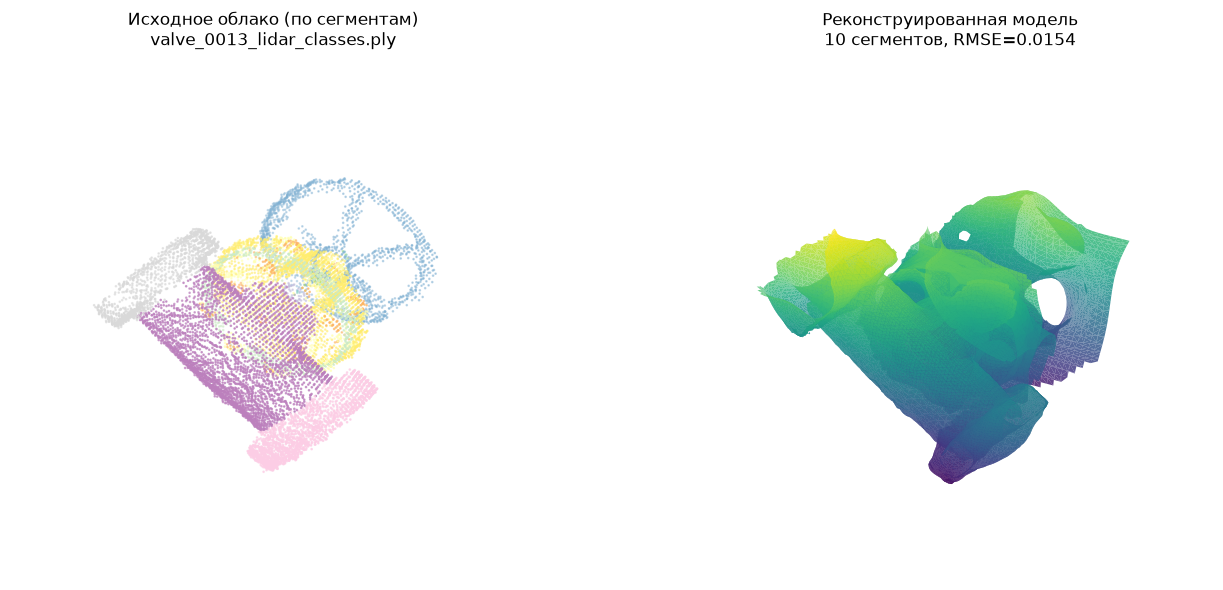

In [19]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

sample_file = files[min(12, len(files) - 1)]  # valve_0013 — для примера
mesh, rows, summary = process_one_file(sample_file, save_mesh=False)
pts, lab = load_point_cloud(sample_file)
pts_c, lab_c, _, _ = preprocess(pts, lab)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(pts_c[:, 0], pts_c[:, 1], pts_c[:, 2], c=lab_c, cmap='Set3', s=0.8, alpha=0.9)
ax1.set_title(f'Исходное облако (по сегментам)\n{sample_file.name}')
ax1.set_axis_off()

ax2 = fig.add_subplot(122, projection='3d')
if len(mesh.vertices) > 0:
    verts = np.asarray(mesh.vertices); tris = np.asarray(mesh.triangles)
    ax2.plot_trisurf(verts[:, 0], verts[:, 1], tris, verts[:, 2],
                     cmap='viridis', alpha=0.85, linewidth=0)
    ax2.set_title(f'Реконструированная модель\n{summary["n_segments"]} сегментов, '
                  f'RMSE={summary["global_rmse"]:.4f}')
else:
    ax2.set_title('Реконструкция пуста')
ax2.set_axis_off()
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'recon_example.png', dpi=120); plt.show()

## 15. Выводы

1. Собран end-to-end pipeline на датасете `5/` (500 облаков клапанов с разметкой `scalar_Label`).
2. Сегментация по готовому `label` + PCA-признаки (linearity / planarity / sphericity) и
   согласованность нормалей позволяют отнести сегмент к `plane` / `tube` / `sphere` / `complex`.
3. Адаптивный выбор реконструкции:
   - **plane** → Alpha Shape,
   - **tube** → Ball Pivoting,
   - **sphere / complex** → Poisson.
4. Для оценки качества использованы RMSE, Hausdorff-p95, Chamfer и число компонент mesh.
5. Сравнение всех трёх методов на одних сегментах (раздел 13) показывает, что переключение
   по типу геометрии даёт более стабильный результат, чем один алгоритм на весь датасет.

